In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

elev = 25
azim = -60
arrow_scale = 0.15
seg_colors = ['#d62728', '#ff7f0e', '#9467bd']

def plot_scene(ax, segments, touchdown_point, bellmouth,
               V_wave=None, show_velocities=True, show_forces=False, show_moments=False,
               M_touchdown=None, M_bellmouth=None):
    all_points = np.array([seg['start'] for seg in segments] + [segments[-1]['end']])
    x_range = [all_points[:,0].min() - 0.5, all_points[:,0].max() + 0.5]
    z_range = [0, all_points[:,2].max() + 0.5]
    
    ax.plot3D([x_range[0], x_range[1]], [0, 0], [0, 0], 'k-', linewidth=0.5, alpha=0.3)
    ax.plot3D([0, 0], [-1, 1], [0, 0], 'k-', linewidth=0.5, alpha=0.3)
    ax.plot3D([0, 0], [0, 0], [0, z_range[1]], 'k-', linewidth=0.5, alpha=0.3)
    
    for seg in segments:
        color = seg_colors[(seg['index'] - 1) % len(seg_colors)]
        ax.plot3D([seg['start'][0], seg['end'][0]],
                  [seg['start'][1], seg['end'][1]],
                  [seg['start'][2], seg['end'][2]],
                  '-', color=color, linewidth=4, solid_capstyle='round',
                  label=f"Seg {seg['index']} (θ={seg['theta_vert']}°)")
    
    ax.scatter(*touchdown_point, color='black', s=80, marker='s', zorder=5, label='Touchdown')
    ax.scatter(*bellmouth, color='black', s=80, marker='^', zorder=5, label='Bellmouth')
    
    if show_velocities and V_wave is not None and 'V_normal' in segments[0]:
        for i, seg in enumerate(segments):
            if i == 0:
                ax.quiver(*seg['midpoint'], *V_wave, color='blue',
                          arrow_length_ratio=arrow_scale, linewidth=2, label='V_wave')
            if 'V_parallel' in seg:
                ax.quiver(*seg['midpoint'], *seg['V_parallel'], color='orange',
                          arrow_length_ratio=arrow_scale, linewidth=1.5,
                          label='V_parallel' if i == 0 else '')
            ax.quiver(*seg['midpoint'], *seg['V_normal'], color='cyan',
                      arrow_length_ratio=arrow_scale, linewidth=1.5,
                      label='V_normal' if i == 0 else '')
    
    if show_forces and 'F_drag' in segments[0]:
        F_max = max(np.linalg.norm(seg['F_drag']) for seg in segments)
        F_scale = 0.3 / F_max if F_max > 0 else 1
        for i, seg in enumerate(segments):
            ax.quiver(*seg['midpoint'], *(seg['F_drag'] * F_scale), color='green',
                      arrow_length_ratio=arrow_scale, linewidth=2,
                      label=f'F_drag (scaled)' if i == 0 else '')
    
    if show_moments and M_touchdown is not None and M_bellmouth is not None:
        M_max = max(np.linalg.norm(M_touchdown), np.linalg.norm(M_bellmouth))
        M_scale = 0.4 / M_max if M_max > 0 else 1
        ax.quiver(*touchdown_point, *(M_touchdown * M_scale), color='magenta',
                  arrow_length_ratio=arrow_scale, linewidth=2, label='M (scaled)')
        ax.quiver(*bellmouth, *(M_bellmouth * M_scale), color='magenta',
                  arrow_length_ratio=arrow_scale, linewidth=2)
    
    ax.set_xlabel('x (East)')
    ax.set_ylabel('y (North)')
    ax.set_zlabel('z (Up)')
    ax.set_box_aspect([1, 1, 1])

In [2]:
# Hs, direction
# Tp
# Uc, direction



# Input parameters
theta_heading = 0      # CPS heading (degrees from true north, same for all segments)
theta_wave = 180        # Wave heading ('going to' convention)
V_wave_mag = 0.5        # Wave velocity magnitude (m/s)

# CPS segment definition (from TOUCHDOWN to BELLMOUTH)
# Each segment: [length (m), vertical angle (deg from horizontal)]
# Angle: 0° = horizontal, 90° = vertical
segments_def = [
    [1, 10],   # Segment 1: near touchdown (almost horizontal)
    [1, 45],   # Segment 2: middle transition
    [1, 60],   # Segment 3: near bellmouth (almost vertical)
]

# CPS physical properties (same for all segments)
CPS_diameter = 0.1  # m
rho = 1025          # kg/m³
Cd = 1.2            # drag coefficient

# Touchdown point location (origin of the CPS chain)
touchdown_point = np.array([3, 0, 0])

In [3]:
# wave/current direction vector (horizontal plane)
V_wave_dir = np.array([
    math.sin(math.radians(theta_wave)),
    math.cos(math.radians(theta_wave)),
    0])

V_wave = np.round(V_wave_mag * V_wave_dir, 3)
V_wave_norm = np.linalg.norm(V_wave)

print(f"V_wave = [{V_wave[0]:.2f}, {V_wave[1]:.2f}, {V_wave[2]:.2f}] m/s")
print(f"V_wave_norm = {V_wave_norm:.2f} m/s")
print(f"This should be zero: {V_wave_norm - V_wave_mag:.2f} m/s")

V_wave = [0.00, -0.50, 0.00] m/s
V_wave_norm = 0.50 m/s
This should be zero: 0.00 m/s


In [4]:
# CPS segments definition
segments = []
current_point = touchdown_point.copy()

for i, (length, theta_vert) in enumerate(segments_def):
    # Segment direction vector (pointing from touchdown toward bellmouth)
    # Negative horizontal component because we go "inward" toward the platform
    seg_axis = np.array([
        -math.cos(math.radians(theta_vert)) * math.sin(math.radians(theta_heading)),
        -math.cos(math.radians(theta_vert)) * math.cos(math.radians(theta_heading)),
         math.sin(math.radians(theta_vert))
    ])
    
    start = current_point.copy()
    end = start + length * seg_axis
    midpoint = (start + end) / 2
    
    segments.append({
        'index': i + 1,
        'length': length,
        'theta_vert': theta_vert,
        'axis': seg_axis,
        'start': start,
        'end': end,
        'midpoint': midpoint
    })
    
    current_point = end.copy()

# Fixed points
bellmouth = segments[-1]['end']

# output CPS segment details as table
for seg in segments:
    print(f"Segment {seg['index']}: θ_vert={seg['theta_vert']}°, L={seg['length']}m")
    print(f"  start: {np.round(seg['start'], 2)}")
    print(f"  end:   {np.round(seg['end'], 2)}")

print(f"Touchdown point: {touchdown_point}")
print(f"Bellmouth point: {np.round(bellmouth, 2)}")

Segment 1: θ_vert=10°, L=1m
  start: [3 0 0]
  end:   [ 3.   -0.98  0.17]
Segment 2: θ_vert=45°, L=1m
  start: [ 3.   -0.98  0.17]
  end:   [ 3.   -1.69  0.88]
Segment 3: θ_vert=60°, L=1m
  start: [ 3.   -1.69  0.88]
  end:   [ 3.   -2.19  1.75]
Touchdown point: [3 0 0]
Bellmouth point: [ 3.   -2.19  1.75]


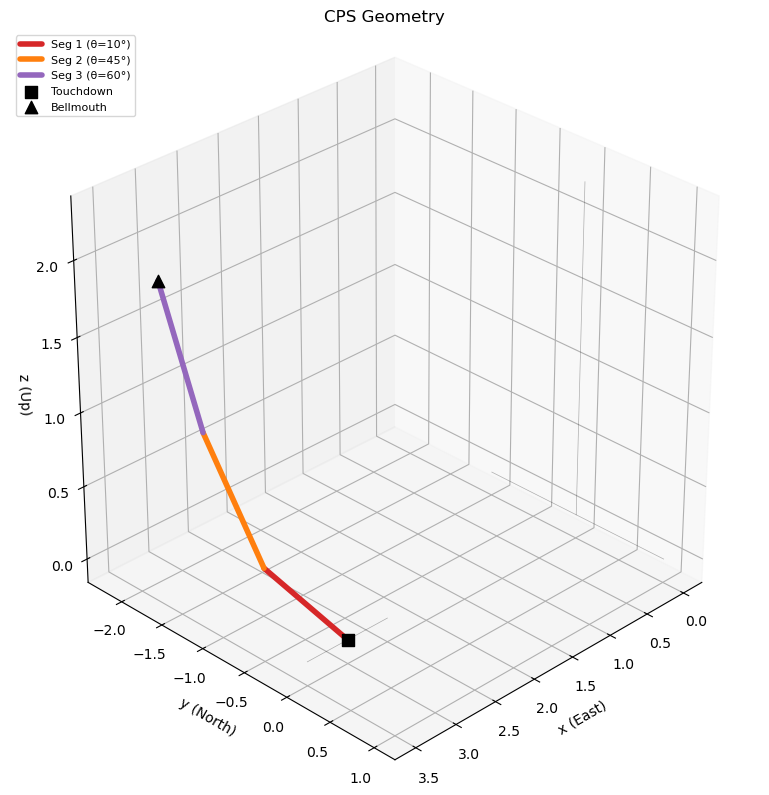

In [5]:
# CPS geometry
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
plot_scene(ax, segments, touchdown_point, bellmouth)
ax.view_init(elev=30, azim=45)
ax.set_title('CPS Geometry')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# velocity decomposition per segment

for seg in segments:
    V_parallel_scalar = np.dot(V_wave, seg['axis'])
    V_parallel = V_parallel_scalar * seg['axis']
    V_normal = V_wave - V_parallel

    seg['V_parallel'] = V_parallel
    seg['V_normal'] = V_normal
    seg['V_normal_mag'] = np.linalg.norm(V_normal)

    print(f"Segment {seg['index']} (θ_vert={seg['theta_vert']}°):")
    print(f"  V_parallel = [{V_parallel[0]:+.4f}, {V_parallel[1]:+.4f}, {V_parallel[2]:+.4f}]  |V|={np.linalg.norm(V_parallel):.4f}")
    print(f"  V_normal   = [{V_normal[0]:+.4f}, {V_normal[1]:+.4f}, {V_normal[2]:+.4f}]  |V|={seg['V_normal_mag']:.4f}")
    print(f"  z check: {V_parallel[2]:+.4f} + {V_normal[2]:+.4f} = {V_parallel[2] + V_normal[2]:.1e} (should be 0)")

Segment 1 (θ_vert=10°):
  V_parallel = [-0.0000, -0.4849, +0.0855]  |V|=0.4924
  V_normal   = [+0.0000, -0.0151, -0.0855]  |V|=0.0868
  z check: +0.0855 + -0.0855 = 0.0e+00 (should be 0)
Segment 2 (θ_vert=45°):
  V_parallel = [-0.0000, -0.2500, +0.2500]  |V|=0.3536
  V_normal   = [+0.0000, -0.2500, -0.2500]  |V|=0.3536
  z check: +0.2500 + -0.2500 = 0.0e+00 (should be 0)
Segment 3 (θ_vert=60°):
  V_parallel = [-0.0000, -0.1250, +0.2165]  |V|=0.2500
  V_normal   = [+0.0000, -0.3750, -0.2165]  |V|=0.4330
  z check: +0.2165 + -0.2165 = 0.0e+00 (should be 0)


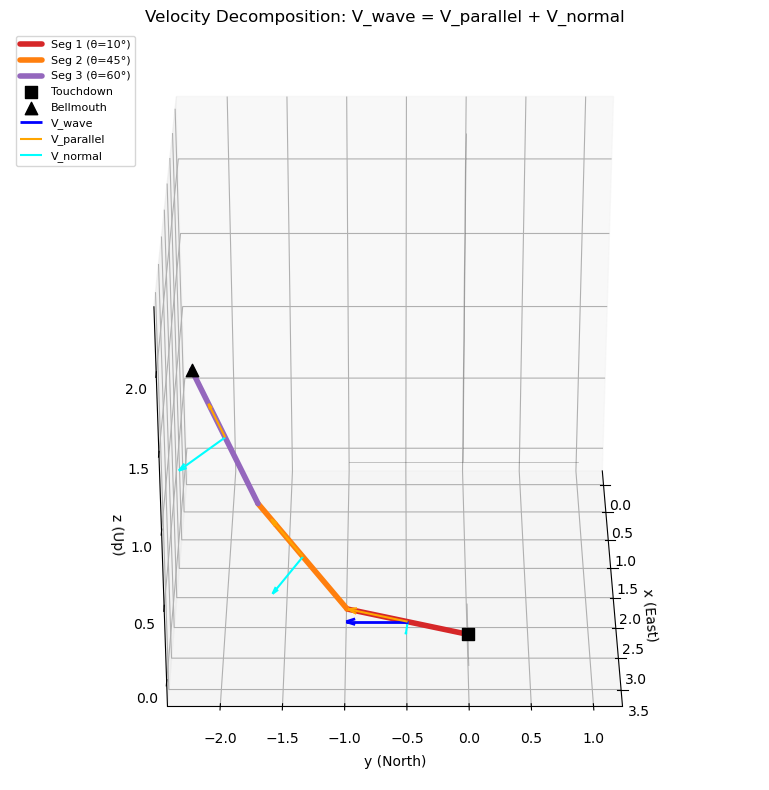

In [7]:
# plot velocity decomposition
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
plot_scene(ax, segments, touchdown_point, bellmouth, V_wave=V_wave)
ax.view_init(elev=30, azim=0)
ax.set_title('Velocity Decomposition: V_wave = V_parallel + V_normal')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# drag force calculation per segment
F_drag_total = np.zeros(3)

for seg in segments:
    V_n = seg['V_normal_mag']
    
    # Drag force per unit length: f = 0.5 * rho * Cd * D * V_normal²
    f_per_length = 0.5 * rho * Cd * CPS_diameter * V_n**2  # N/m
    
    # Total drag force on segment
    F_mag = f_per_length * seg['length']
    F_dir = seg['V_normal'] / V_n if V_n > 0 else np.zeros(3)
    F_drag = F_mag * F_dir
    
    seg['f_drag_per_length'] = f_per_length
    seg['F_drag'] = F_drag
    
    F_drag_total += F_drag
    
    print(f"Segment {seg['index']}: |F_drag| = {F_mag:.4f} N")
    print(f"  F_drag = {np.round(F_drag, 2)} N")

print(f"Total drag force: {np.round(F_drag_total, 2)} N")
print(f"|F_total| = {np.linalg.norm(F_drag_total):.2f} N")

Segment 1: |F_drag| = 0.4636 N
  F_drag = [ 0.   -0.08 -0.46] N
Segment 2: |F_drag| = 7.6875 N
  F_drag = [ 0.   -5.44 -5.44] N
Segment 3: |F_drag| = 11.5312 N
  F_drag = [ 0.   -9.99 -5.77] N
Total drag force: [  0.   -15.5  -11.66] N
|F_total| = 19.40 N


In [9]:
# moment calculation
# so, each segment's drag force should create a moment force about both fixed ends (arguable)
# moment is defined as M = r × F, r is the vector from  fixed point to where force is applied

M_touchdown = np.zeros(3)  # Total moment at touchdown point
M_bellmouth = np.zeros(3)  # Total moment at bellmouth

for seg in segments:
    # position vectors from fixed points to segment midpoint
    r_from_touchdown = seg['midpoint'] - touchdown_point
    r_from_bellmouth = seg['midpoint'] - bellmouth
    
    # cross product to get moment
    M_seg_touchdown = np.cross(r_from_touchdown, seg['F_drag'])
    M_seg_bellmouth = np.cross(r_from_bellmouth, seg['F_drag'])
    
    seg['M_touchdown'] = M_seg_touchdown
    seg['M_bellmouth'] = M_seg_bellmouth
    
    M_touchdown += M_seg_touchdown
    M_bellmouth += M_seg_bellmouth
    
    print(f"Segment {seg['index']}:")
    print(f"  r_touchdown = {np.round(r_from_touchdown, 2)}")
    print(f"  M at touchdown: {np.round(M_seg_touchdown, 2)} N·m")
    print(f"  M at bellmouth: {np.round(M_seg_bellmouth,2)} N·m")

print(f"TOTAL moment at touchdown: {np.round(M_touchdown, 2)} N·m")
print(f"  |M_touchdown| = {np.linalg.norm(M_touchdown):.2f} N·m")
print(f"TOTAL moment at bellmouth: {np.round(M_bellmouth, 2)} N·m")
print(f"  |M_bellmouth| = {np.linalg.norm(M_bellmouth):.2f} N·m")

Segment 1:
  r_touchdown = [ 0.   -0.49  0.09]
  M at touchdown: [0.23 0.   0.  ] N·m
  M at bellmouth: [-0.91  0.   -0.  ] N·m
Segment 2:
  r_touchdown = [ 0.   -1.34  0.53]
  M at touchdown: [10.14  0.    0.  ] N·m
  M at bellmouth: [-11.27   0.    -0.  ] N·m
Segment 3:
  r_touchdown = [ 0.   -1.94  1.31]
  M at touchdown: [24.32  0.    0.  ] N·m
  M at bellmouth: [-5.77  0.   -0.  ] N·m
TOTAL moment at touchdown: [34.69  0.    0.  ] N·m
  |M_touchdown| = 34.69 N·m
TOTAL moment at bellmouth: [-17.94   0.     0.  ] N·m
  |M_bellmouth| = 17.94 N·m


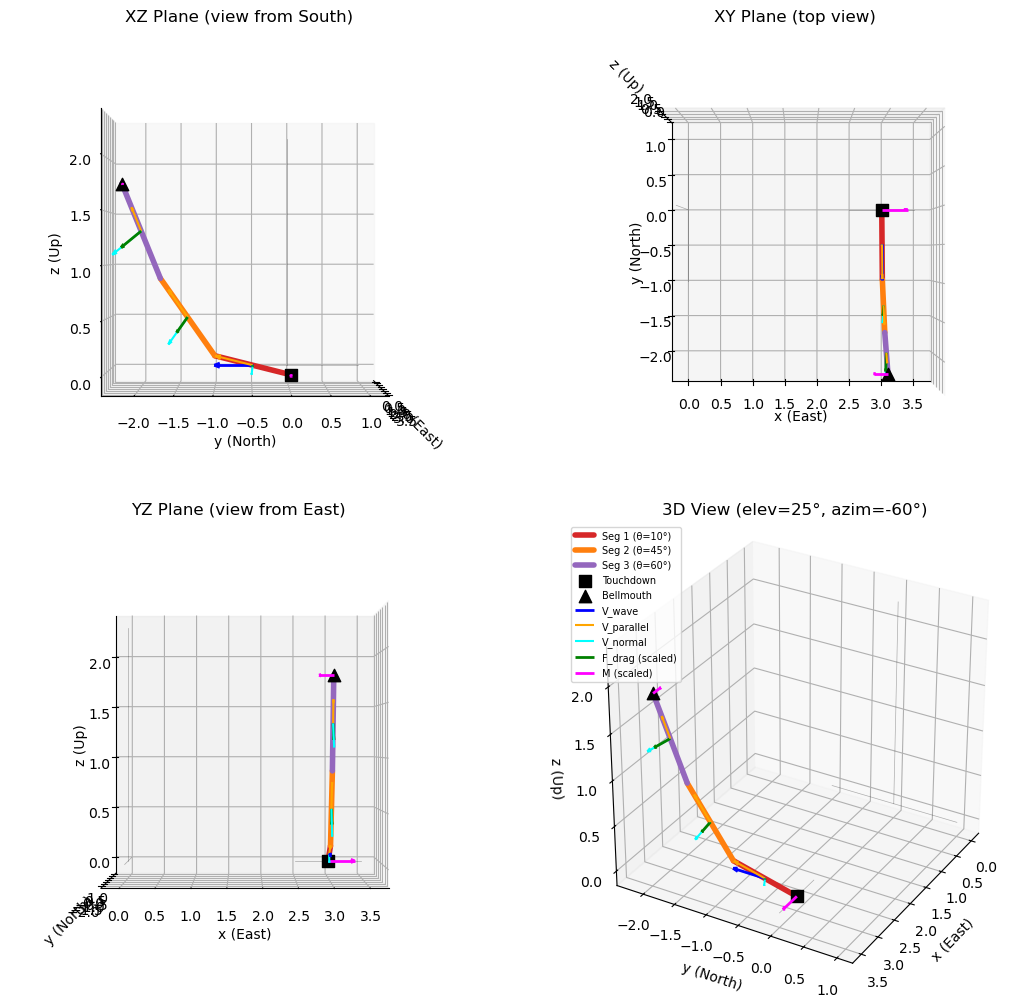

In [10]:
# 2x2 subplot: XZ, XY, YZ planes + configurable 3D view
fig = plt.figure(figsize=(12, 10))

# XZ plane (view from South)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
plot_scene(ax1, segments, touchdown_point, bellmouth, V_wave, 
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax1.view_init(elev=0, azim=0)
ax1.set_title('XZ Plane (view from South)')

# XY plane (top view)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
plot_scene(ax2, segments, touchdown_point, bellmouth, V_wave,
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax2.view_init(elev=90, azim=-90)
ax2.set_title('XY Plane (top view)')

# YZ plane (view from East)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
plot_scene(ax3, segments, touchdown_point, bellmouth, V_wave,
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax3.view_init(elev=0, azim=-90)
ax3.set_title('YZ Plane (view from East)')

# Configurable 3D view
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
plot_scene(ax4, segments, touchdown_point, bellmouth, V_wave,
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax4.view_init(elev=30, azim=30)
ax4.set_title(f'3D View (elev={elev}°, azim={azim}°)')
ax4.legend(loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

In [11]:
# alternative moment calculation: fixed-fixed beam model
# treats the CPS as a 1D fixed-fixed Euler-Bernoulli beam of length L (total arc length)
# each segment's normal drag force magnitude is a point load at its arc-length position
# convention: x=0 at touchdown, x=L at bellmouth (follows segment ordering in this notebook)

L_beam = sum(seg['length'] for seg in segments)

# arc-length to each segment midpoint (where loads act)
load_pos = []
acc = 0.0
for seg in segments:
    load_pos.append(acc + seg['length'] / 2)
    acc += seg['length']

# arc-length to segment edges (n_seg+1 values, 0 to L)
edge_pos = [0.0]
acc = 0.0
for seg in segments:
    acc += seg['length']
    edge_pos.append(acc)

midspan_pos = L_beam / 2

# point loads: (arc-length position, scalar force magnitude)
loads_ff = [(load_pos[i], np.linalg.norm(seg['F_drag'])) for i, seg in enumerate(segments)]

# fixed-fixed end moments (superposition): M_left = -P*a*b^2/L^2, M_right = -P*a^2*b/L^2
M0_ff, ML_ff = 0.0, 0.0
for (a, P) in loads_ff:
    b = L_beam - a
    M0_ff += -P * a * b**2 / L_beam**2
    ML_ff += -P * a**2 * b / L_beam**2

# left shear reaction: R0 = (ML - M0 + sum(P*(L-a))) / L
R0_ff = (ML_ff - M0_ff + sum(P * (L_beam - a) for (a, P) in loads_ff)) / L_beam

# moment at any beam position x
def M_ff_at(x):
    M = M0_ff + R0_ff * x
    for (a, P) in loads_ff:
        if a <= x:
            M -= P * (x - a)
    return M

# key moments
M_tdp_ff = abs(M0_ff)            # x=0 = touchdown
M_bme_ff = abs(ML_ff)            # x=L = bellmouth
M_mid_ff = abs(M_ff_at(midspan_pos))
M_edges_ff = [abs(M_ff_at(ep)) for ep in edge_pos]

# max |M| (evaluate at edges + load positions + midspan — piecewise-linear extrema)
eval_pts = sorted(set(edge_pos + load_pos + [midspan_pos]))
M_max_ff = max(abs(M_ff_at(ep)) for ep in eval_pts)

# sample full beam for plotting
x_beam = np.linspace(0, L_beam, 500)
M_beam = np.array([M_ff_at(xi) for xi in x_beam])

print(f"=== Fixed-Fixed Beam Model ===")
print(f"Beam length (arc length): {L_beam:.2f} m")
print(f"  x=0: touchdown,  x={L_beam:.2f}: bellmouth\n")
for i, (a, P) in enumerate(loads_ff):
    print(f"  Seg {segments[i]['index']}: P = {P:.4f} N at x = {a:.2f} m")
print(f"\nEnd moments:")
print(f"  Touchdown (x=0):    M = {M0_ff:+.4f} N.m,  |M| = {M_tdp_ff:.4f}")
print(f"  Bellmouth (x={L_beam:.0f}):   M = {ML_ff:+.4f} N.m,  |M| = {M_bme_ff:.4f}")
print(f"\nMidspan (x={midspan_pos:.2f} m):  |M| = {M_mid_ff:.4f}")
print(f"\nSegment edge moments:")
for j, ep in enumerate(edge_pos):
    label = "touchdown" if j == 0 else ("bellmouth" if j == len(edge_pos)-1 else f"edge {j}")
    print(f"  {label:>10s} (x={ep:.2f}): |M| = {M_edges_ff[j]:.4f}")
print(f"\nMax |M| anywhere: {M_max_ff:.4f} N.m")

# compare with simple torque from previous cell
print(f"\n--- Comparison with simple torque (M = r x F) ---")
print(f"  {'':>22s}  {'Simple torque':>14s}  {'Fixed-fixed':>12s}")
print(f"  |M| at touchdown:   {np.linalg.norm(M_touchdown):>14.4f}  {M_tdp_ff:>12.4f}")
print(f"  |M| at bellmouth:   {np.linalg.norm(M_bellmouth):>14.4f}  {M_bme_ff:>12.4f}")

=== Fixed-Fixed Beam Model ===
Beam length (arc length): 3.00 m
  x=0: touchdown,  x=3.00: bellmouth

  Seg 1: P = 0.4636 N at x = 0.50 m
  Seg 2: P = 7.6875 N at x = 1.50 m
  Seg 3: P = 11.5312 N at x = 2.50 m

End moments:
  Touchdown (x=0):    M = -3.8446 N.m,  |M| = 3.8446
  Bellmouth (x=3):   M = -6.9189 N.m,  |M| = 6.9189

Midspan (x=1.50 m):  |M| = 3.3826

Segment edge moments:
   touchdown (x=0.00): |M| = 3.8446
      edge 1 (x=1.00): |M| = 1.0508
      edge 2 (x=2.00): |M| = 1.8706
   bellmouth (x=3.00): |M| = 6.9189

Max |M| anywhere: 6.9189 N.m

--- Comparison with simple torque (M = r x F) ---
                           Simple torque   Fixed-fixed
  |M| at touchdown:          34.6889        3.8446
  |M| at bellmouth:          17.9445        6.9189


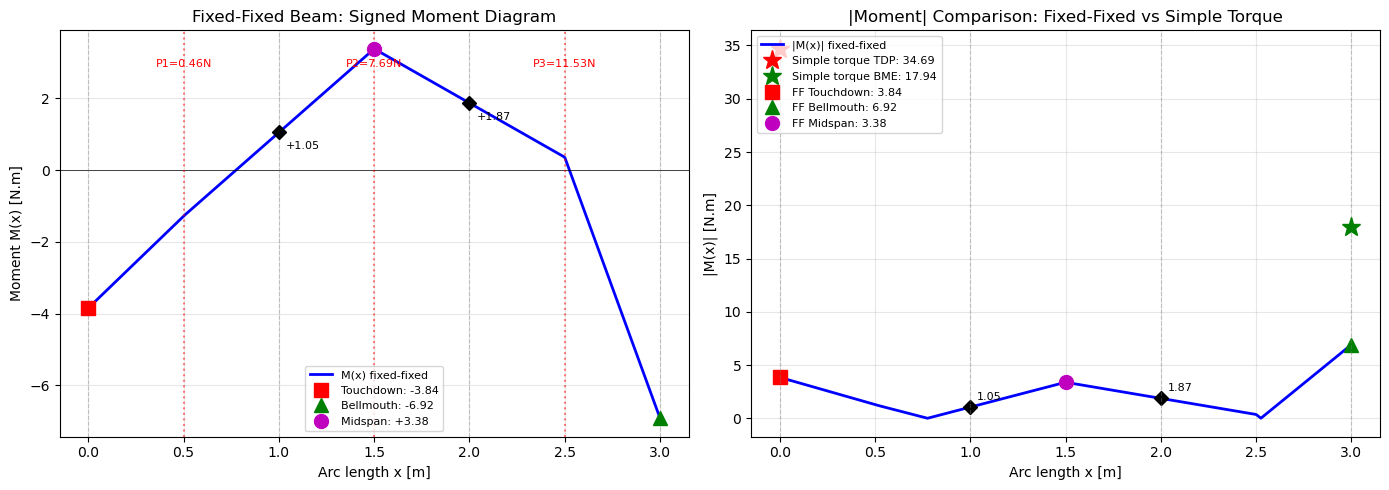

In [12]:
# moment distribution visualisation: fixed-fixed beam model

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: signed M(x) ---
ax = axes[0]
ax.plot(x_beam, M_beam, 'b-', linewidth=2, label='M(x) fixed-fixed')
ax.axhline(y=0, color='k', linewidth=0.5)

# segment edges (vertical dashed)
for j, ep in enumerate(edge_pos):
    ax.axvline(x=ep, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

# load positions
for i, (a, P) in enumerate(loads_ff):
    ax.axvline(x=a, color='red', linestyle=':', alpha=0.5)
    yoff = max(M_beam) * 0.85
    ax.annotate(f'P{i+1}={P:.2f}N', xy=(a, yoff), fontsize=8, ha='center', color='red')

# key points
ax.plot(0, M0_ff, 'rs', markersize=10, label=f'Touchdown: {M0_ff:+.2f}')
ax.plot(L_beam, ML_ff, 'g^', markersize=10, label=f'Bellmouth: {ML_ff:+.2f}')
ax.plot(midspan_pos, M_ff_at(midspan_pos), 'mo', markersize=10, label=f'Midspan: {M_ff_at(midspan_pos):+.2f}')

# interior edge moments
for j in range(1, len(edge_pos) - 1):
    ep = edge_pos[j]
    M_val = M_ff_at(ep)
    ax.plot(ep, M_val, 'kD', markersize=7)
    ax.annotate(f'{M_val:+.2f}', xy=(ep, M_val), textcoords='offset points',
                xytext=(5, -12), fontsize=8)

ax.set_xlabel('Arc length x [m]')
ax.set_ylabel('Moment M(x) [N.m]')
ax.set_title('Fixed-Fixed Beam: Signed Moment Diagram')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: |M(x)| with simple torque comparison ---
ax = axes[1]
ax.plot(x_beam, np.abs(M_beam), 'b-', linewidth=2, label='|M(x)| fixed-fixed')

# simple torque endpoints for reference
M_tdp_simple = np.linalg.norm(M_touchdown)
M_bme_simple = np.linalg.norm(M_bellmouth)
ax.plot(0, M_tdp_simple, 'r*', markersize=14, zorder=5, label=f'Simple torque TDP: {M_tdp_simple:.2f}')
ax.plot(L_beam, M_bme_simple, 'g*', markersize=14, zorder=5, label=f'Simple torque BME: {M_bme_simple:.2f}')

# fixed-fixed key points
ax.plot(0, M_tdp_ff, 'rs', markersize=10, label=f'FF Touchdown: {M_tdp_ff:.2f}')
ax.plot(L_beam, M_bme_ff, 'g^', markersize=10, label=f'FF Bellmouth: {M_bme_ff:.2f}')
ax.plot(midspan_pos, M_mid_ff, 'mo', markersize=10, label=f'FF Midspan: {M_mid_ff:.2f}')

# segment edges
for j in range(1, len(edge_pos) - 1):
    ep = edge_pos[j]
    ax.plot(ep, M_edges_ff[j], 'kD', markersize=7)
    ax.annotate(f'{M_edges_ff[j]:.2f}', xy=(ep, M_edges_ff[j]),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# edge dashed lines
for ep in edge_pos:
    ax.axvline(x=ep, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

ax.set_xlabel('Arc length x [m]')
ax.set_ylabel('|M(x)| [N.m]')
ax.set_title('|Moment| Comparison: Fixed-Fixed vs Simple Torque')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

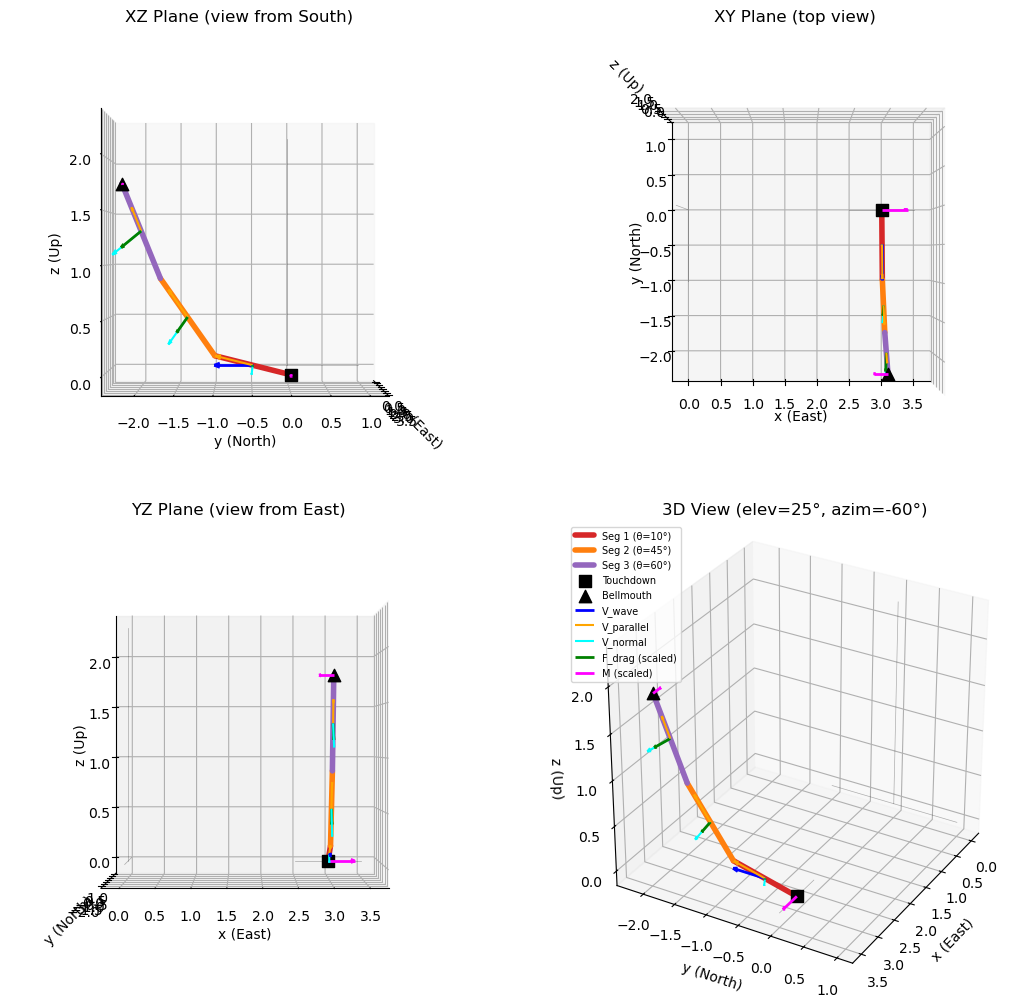

In [15]:
# 2x2 subplot: XZ, XY, YZ planes + configurable 3D view
fig = plt.figure(figsize=(12, 10))

# XZ plane (view from South)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
plot_scene(ax1, segments, touchdown_point, bellmouth, V_wave, 
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax1.view_init(elev=0, azim=0)
ax1.set_title('XZ Plane (view from South)')

# XY plane (top view)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
plot_scene(ax2, segments, touchdown_point, bellmouth, V_wave,
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax2.view_init(elev=90, azim=-90)
ax2.set_title('XY Plane (top view)')

# YZ plane (view from East)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
plot_scene(ax3, segments, touchdown_point, bellmouth, V_wave,
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax3.view_init(elev=0, azim=-90)
ax3.set_title('YZ Plane (view from East)')

# Configurable 3D view
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
plot_scene(ax4, segments, touchdown_point, bellmouth, V_wave,
           show_forces=True, show_moments=True, M_touchdown=M_touchdown, M_bellmouth=M_bellmouth)
ax4.view_init(elev=30, azim=30)
ax4.set_title(f'3D View (elev={elev}°, azim={azim}°)')
ax4.legend(loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

In [13]:
# contribution of Tp
# we should split wave and current horizontal velocities tho
Tp = 8  # seconds (this should come from metocean)
n_cycles = 3600 / Tp # how many back and forth cycles in one hour

# assumption: fatigue ∝ n*stress^m (Sn curve) and stress ∝ moment ∝ V^2
# so we could say: fatigue ∝ n * (moment)^m
FLS_proxy_tdp = n_cycles * (np.linalg.norm(M_touchdown))**3  # assuming m=3 (need to check this)
FLS_proxy_bme = n_cycles * (np.linalg.norm(M_bellmouth))**3  # bme = bellmouth exit

print(f"FLS proxy at touchdown: {FLS_proxy_tdp:.2e}")
print(f"FLS proxy at bellmouth: {FLS_proxy_bme:.2e}")


FLS proxy at touchdown: 1.88e+07
FLS proxy at bellmouth: 2.60e+06


In [14]:
# slight digression:
# shouldn't the moment at tdp be generated by the forces up until
# the mid of the CPS catenary (for 3 segments, split the force of seg 2 in half)
# and similarly for bellmouth, the moment should be from forces until 
# the mid point of the catenary??????